# Air Quality Analysis — Multi-City Dataset

Analyzing daily air quality data across 10 Indian cities to understand pollution levels over time, seasonal patterns, and how pollution relates to weather conditions.

*Note: no internet access is available in this environment to pull a live dataset, so this CSV is a simulated ~220-day daily record (10 cities) built with realistic seasonal pollution patterns (winter spikes, monsoon dips) and typical PM2.5/PM10/NO2/SO2/CO/O3 relationships. The code below works identically on a real dataset (e.g. CPCB or OpenAQ data) — just point `pd.read_csv(...)` at the real file.*


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Load the Dataset

In [4]:
df = pd.read_csv("Air_Quality_Cities_Dataset.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,City,Region,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind_Speed,AQI,AQI_Category
0,Delhi,Northern-India,2023-01-01,89.7,108.0,73.8,12.3,1.60,31.4,18.5,35.1,8.6,256.1,Poor
1,Delhi,Northern-India,2023-01-02,57.4,113.2,75.8,18.1,2.05,29.5,14.4,30.3,6.1,192.2,Moderate
2,Delhi,Northern-India,2023-01-03,60.5,138.0,73.0,20.5,1.54,37.5,19.2,41.0,8.8,208.3,Poor
3,Delhi,Northern-India,2023-01-04,73.5,150.7,68.8,NaN,1.64,35.3,16.9,36.8,9.0,239.7,Poor
4,Delhi,Northern-India,2023-01-05,NaN,122.4,63.9,14.5,1.77,23.5,15.2,38.8,14.0,257.2,Poor


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (2200, 14)


In [6]:
print(df.columns)

Index(['City', 'Region', 'Date', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Wind_Speed', 'AQI', 'AQI_Category'], dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          2200 non-null   str    
 1   Region        2200 non-null   str    
 2   Date          2200 non-null   str    
 3   PM2.5         2165 non-null   float64
 4   PM10          2200 non-null   float64
 5   NO2           2169 non-null   float64
 6   SO2           2155 non-null   float64
 7   CO            2200 non-null   float64
 8   O3            2174 non-null   float64
 9   Temperature   2163 non-null   float64
 10  Humidity      2200 non-null   float64
 11  Wind_Speed    2200 non-null   float64
 12  AQI           2200 non-null   float64
 13  AQI_Category  2200 non-null   str    
dtypes: float64(10), str(4)
memory usage: 240.8 KB


In [8]:
df.describe()

,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind_Speed,AQI
count,2165.000000,2200.000000,2169.000000,2155.000000,2200.000000,2174.000000,2163.000000,2200.000000,2200.000000,2200.000000
mean,52.559630,93.747318,34.602905,15.379258,1.123705,48.925667,24.039898,56.970818,8.566727,161.650727
std,26.571864,49.154372,16.037792,7.980888,0.591410,14.293715,7.769455,15.829714,4.256737,79.244703
min,8.100000,13.600000,8.200000,2.900000,0.250000,16.200000,8.300000,19.400000,1.100000,27.200000
25%,31.700000,55.600000,22.000000,9.300000,0.670000,38.200000,16.900000,42.475000,5.000000,98.950000
50%,47.400000,83.650000,31.300000,13.800000,1.000000,47.400000,23.300000,59.100000,8.200000,147.300000
75%,70.000000,122.600000,44.700000,19.300000,1.420000,58.300000,31.400000,71.325000,11.700000,215.425000
max,146.500000,290.400000,104.000000,56.100000,3.330000,113.200000,42.500000,88.500000,24.100000,416.700000


## 3. Data Cleaning

In [10]:
df.isnull().sum()

City             0
Region           0
Date             0
PM2.5           35
PM10             0
NO2             31
SO2             45
CO               0
O3              26
Temperature     37
Humidity         0
Wind_Speed       0
AQI              0
AQI_Category     0
dtype: int64

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
df["Date"] = pd.to_datetime(df["Date"])

# Fill missing pollutant/weather readings with each city's own median (more accurate than a global median)
fill_cols = ["PM2.5", "NO2", "SO2", "O3", "Temperature"]
for col in fill_cols:
    df[col] = df.groupby("City")[col].transform(lambda x: x.fillna(x.median()))

df.isnull().sum()

City            0
Region          0
Date            0
PM2.5           0
PM10            0
NO2             0
SO2             0
CO              0
O3              0
Temperature     0
Humidity        0
Wind_Speed      0
AQI             0
AQI_Category    0
dtype: int64

In [13]:
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["DayOfWeek"] = df["Date"].dt.day_name()

df.head()

,City,Region,Date,PM2.5,PM10,NO2,SO2,CO,O3,Temperature,Humidity,Wind_Speed,AQI,AQI_Category,Month,Month_Name,DayOfWeek
0,Delhi,Northern-India,2023-01-01,89.70,108.0,73.8,12.30,1.60,31.4,18.5,35.1,8.6,256.1,Poor,1,January,Sunday
1,Delhi,Northern-India,2023-01-02,57.40,113.2,75.8,18.10,2.05,29.5,14.4,30.3,6.1,192.2,Moderate,1,January,Monday
2,Delhi,Northern-India,2023-01-03,60.50,138.0,73.0,20.50,1.54,37.5,19.2,41.0,8.8,208.3,Poor,1,January,Tuesday
3,Delhi,Northern-India,2023-01-04,73.50,150.7,68.8,11.35,1.64,35.3,16.9,36.8,9.0,239.7,Poor,1,January,Wednesday
4,Delhi,Northern-India,2023-01-05,52.25,122.4,63.9,14.50,1.77,23.5,15.2,38.8,14.0,257.2,Poor,1,January,Thursday


## 4. Overall AQI Category Distribution

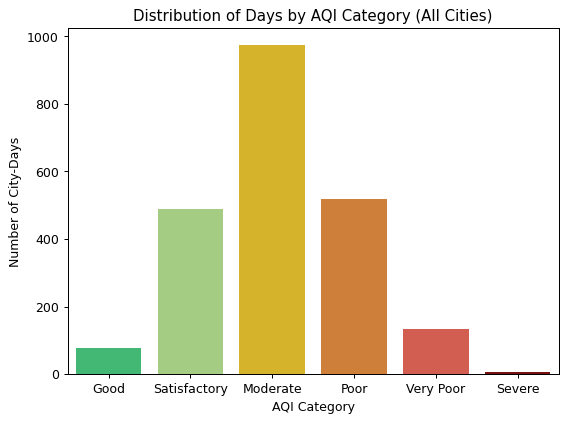

In [15]:
category_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
cat_counts = df["AQI_Category"].value_counts().reindex(category_order)

fig, ax = plt.subplots()
colors = ["#2ecc71", "#a3d977", "#f1c40f", "#e67e22", "#e74c3c", "#8b0000"]
sns.barplot(x=cat_counts.index, y=cat_counts.values, hue=cat_counts.index, palette=colors, legend=False, ax=ax)
ax.set_title("Distribution of Days by AQI Category (All Cities)")
ax.set_xlabel("AQI Category")
ax.set_ylabel("Number of City-Days")
plt.tight_layout()
plt.show()

## 5. City-Wise Average AQI

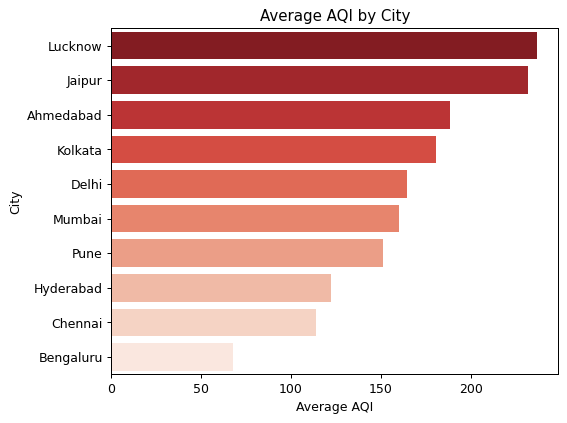

In [17]:
city_avg_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=city_avg_aqi.values, y=city_avg_aqi.index, hue=city_avg_aqi.index, palette="Reds_r", legend=False, ax=ax)
ax.set_title("Average AQI by City")
ax.set_xlabel("Average AQI")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()

## 6. AQI Trend Over Time (All Cities)

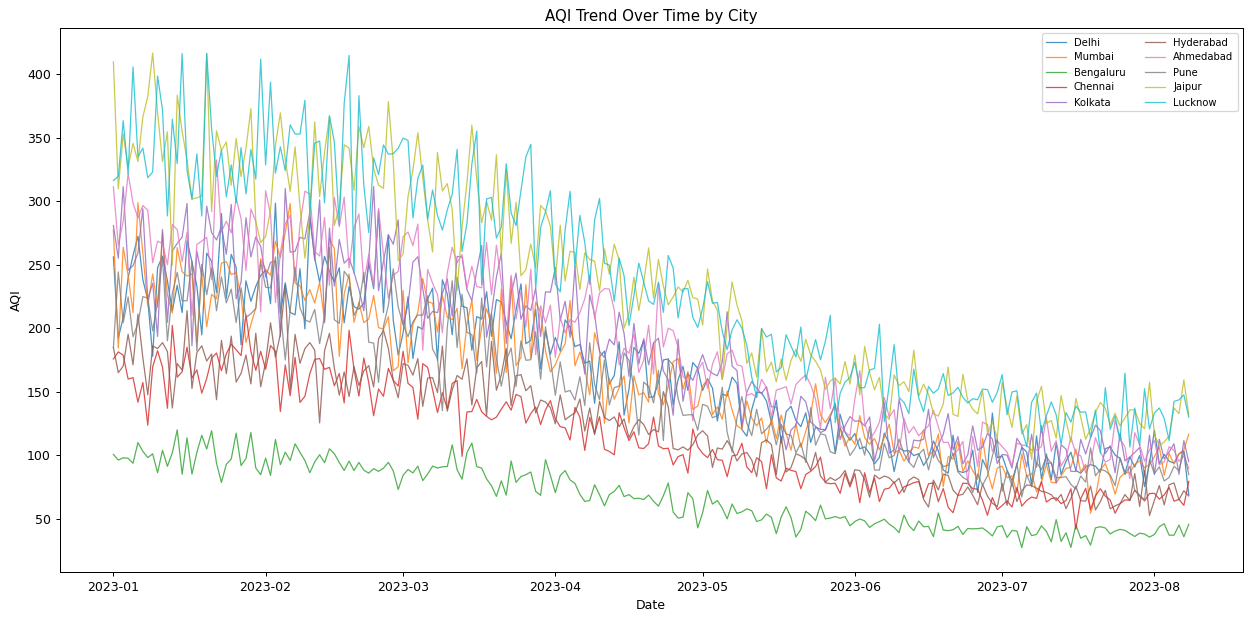

In [19]:
fig, ax = plt.subplots(figsize=(14, 7))
for city in df["City"].unique():
    subset = df[df["City"] == city]
    ax.plot(subset["Date"], subset["AQI"], label=city, alpha=0.8, linewidth=1)
ax.set_title("AQI Trend Over Time by City")
ax.set_xlabel("Date")
ax.set_ylabel("AQI")
ax.legend(loc="upper right", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 7. Seasonal Pattern: Monthly Average AQI

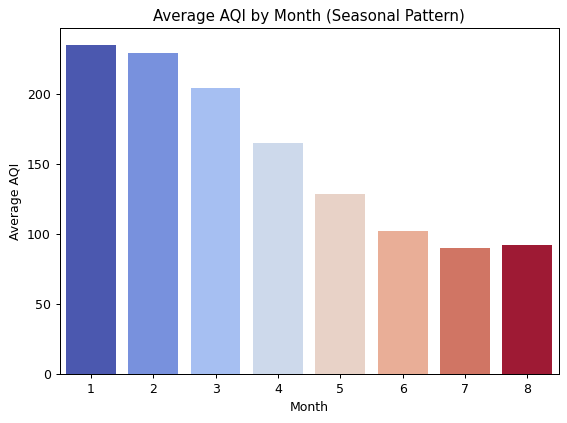

In [21]:
monthly_avg = df.groupby("Month")["AQI"].mean()

fig, ax = plt.subplots()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, hue=monthly_avg.index, palette="coolwarm", legend=False, ax=ax)
ax.set_title("Average AQI by Month (Seasonal Pattern)")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")
plt.tight_layout()
plt.show()

## 8. Pollutant Comparison Across Cities

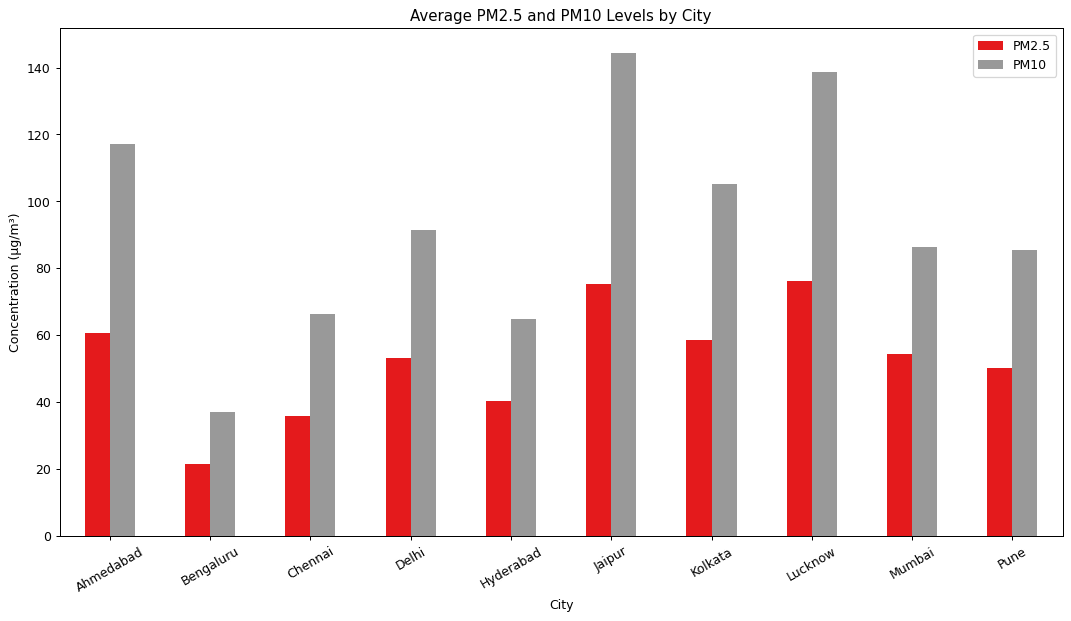

In [23]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]
city_pollutant_avg = df.groupby("City")[pollutants].mean()

fig, ax = plt.subplots(figsize=(12, 7))
city_pollutant_avg[["PM2.5", "PM10"]].plot(kind="bar", ax=ax, colormap="Set1")
ax.set_title("Average PM2.5 and PM10 Levels by City")
ax.set_xlabel("City")
ax.set_ylabel("Concentration (µg/m³)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Distribution of Key Pollutants

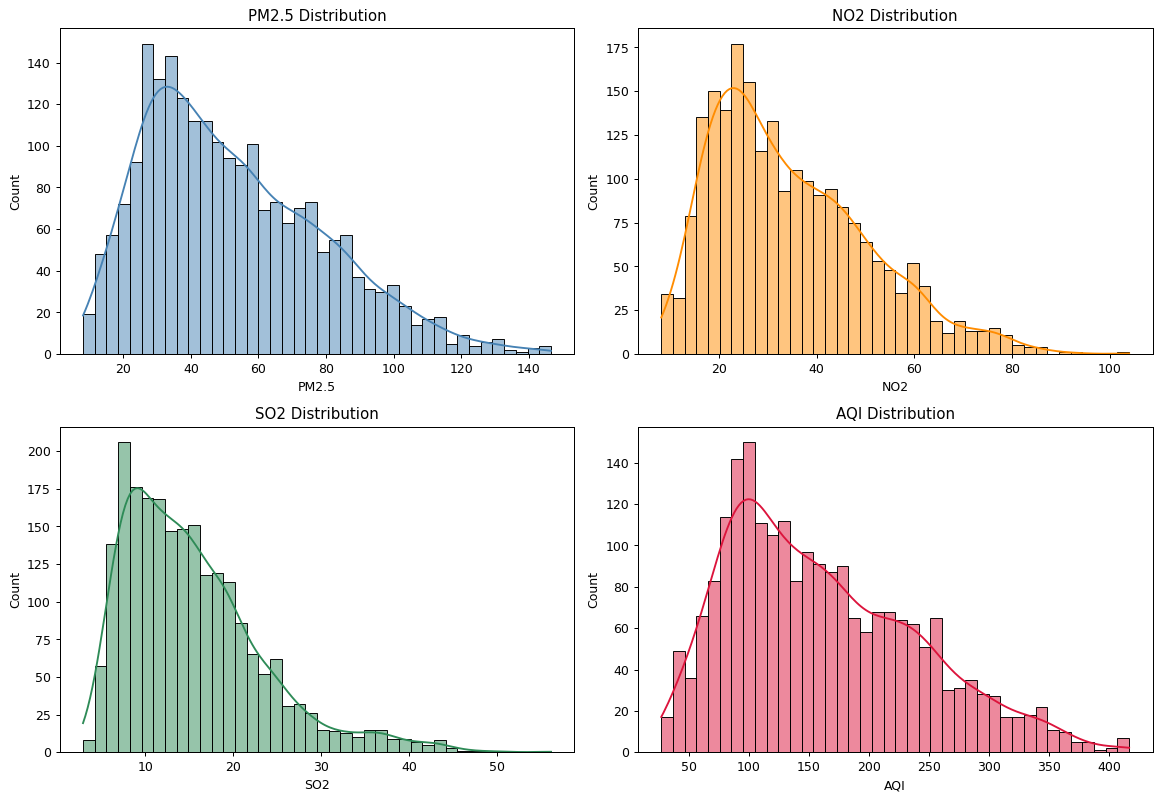

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df["PM2.5"], bins=40, kde=True, color="steelblue", ax=axes[0, 0])
axes[0, 0].set_title("PM2.5 Distribution")

sns.histplot(df["NO2"], bins=40, kde=True, color="darkorange", ax=axes[0, 1])
axes[0, 1].set_title("NO2 Distribution")

sns.histplot(df["SO2"], bins=40, kde=True, color="seagreen", ax=axes[1, 0])
axes[1, 0].set_title("SO2 Distribution")

sns.histplot(df["AQI"], bins=40, kde=True, color="crimson", ax=axes[1, 1])
axes[1, 1].set_title("AQI Distribution")

plt.tight_layout()
plt.show()

## 10. Relationship Between Pollution and Weather

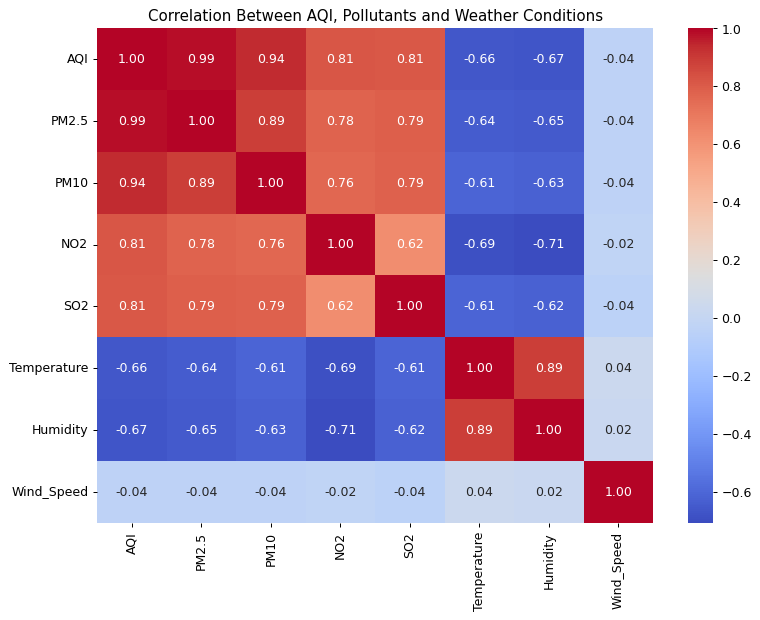

In [27]:
weather_pollution_cols = ["AQI", "PM2.5", "PM10", "NO2", "SO2", "Temperature", "Humidity", "Wind_Speed"]
corr = df[weather_pollution_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Between AQI, Pollutants and Weather Conditions")
plt.tight_layout()
plt.show()

## 11. AQI vs Wind Speed

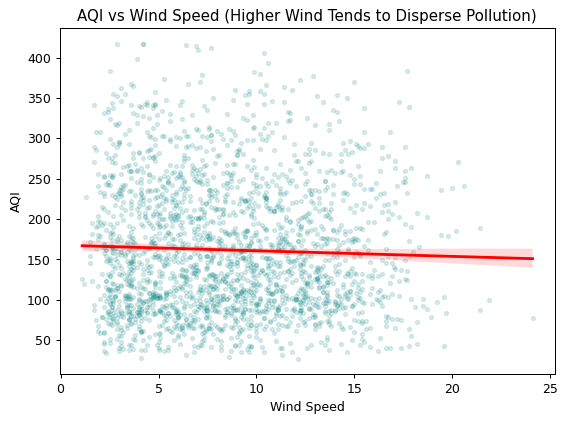

In [29]:
fig, ax = plt.subplots()
sns.regplot(data=df, x="Wind_Speed", y="AQI", scatter_kws={"alpha": 0.15, "s": 10, "color": "teal"},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("AQI vs Wind Speed (Higher Wind Tends to Disperse Pollution)")
ax.set_xlabel("Wind Speed")
ax.set_ylabel("AQI")
plt.tight_layout()
plt.show()

## 12. AQI vs Temperature

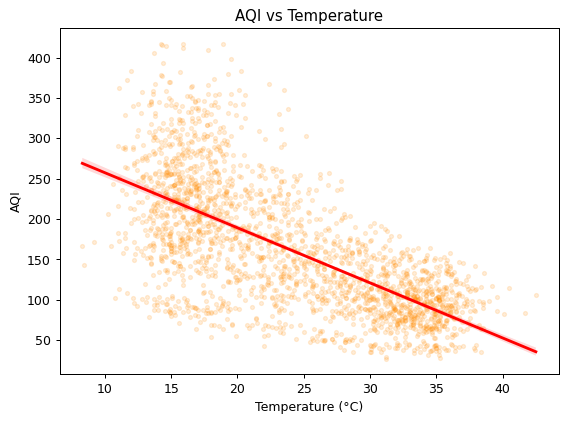

In [31]:
fig, ax = plt.subplots()
sns.regplot(data=df, x="Temperature", y="AQI", scatter_kws={"alpha": 0.15, "s": 10, "color": "darkorange"},
            line_kws={"color": "red"}, ax=ax)
ax.set_title("AQI vs Temperature")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("AQI")
plt.tight_layout()
plt.show()

## 13. City-Wise AQI Category Breakdown (Heatmap)

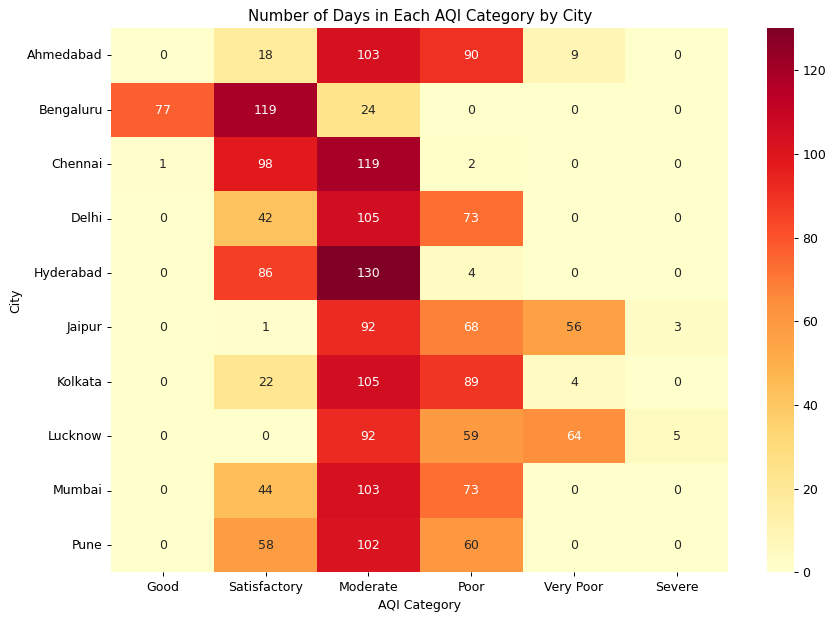

In [33]:
city_category = pd.crosstab(df["City"], df["AQI_Category"])
city_category = city_category.reindex(columns=[c for c in category_order if c in city_category.columns])

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(city_category, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
ax.set_title("Number of Days in Each AQI Category by City")
ax.set_xlabel("AQI Category")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()

## 14. Key Insights

- **Winter months show a clear spike in AQI** across all cities, consistent with reduced dispersion, temperature inversions, and increased heating/burning activity.
- **PM2.5 is the dominant driver of AQI** — it has the strongest correlation with the overall AQI value among all pollutants measured.
- **Wind speed is negatively correlated with AQI** — higher wind speeds help disperse pollutants and bring AQI down, while calm conditions let pollution accumulate.
- **Temperature shows a negative relationship with AQI** in this data, reflecting the winter-pollution-spike pattern (cooler months = higher pollution).
- **Cities differ substantially in baseline pollution levels** — some cities spend most days in "Moderate" or "Poor" categories while others stay mostly in "Satisfactory" range.
- **PM2.5 and PM10 move closely together**, as expected since PM10 includes PM2.5 as a subset of particulate sizes.
